In [2]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

import numpy as np
from scipy.stats import spearmanr
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from mne.stats import spatio_temporal_cluster_test, f_mway_rm, f_threshold_mway_rm, permutation_cluster_1samp_test

In [17]:
def add_subplot_label(ax, label, x=-.21, y=1.225):
    ax.text(x, y, label,  # Adjust left of y-axis
            transform=ax.transAxes,
            fontsize=26, va='top', ha='right')

In [3]:
plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })

In [4]:
path = '/home/common/bonaiuto/stop_go_bursts/derivatives/Dataset_1/'

# combine bursts_all_results and bursts_all_results_cue
bursts_all_results_laplac = np.load(f'{path}/bursts_all_results_laplac.npy', allow_pickle=True)

In [5]:
all_bursts={
    'trial': [],
    'waveform': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
    'waveform_times': [],
    'condition': [],
    'electrode': [],
    'subject': [],
    'experiment': [],
    'epochs': []
}
for bursts in bursts_all_results_laplac:
    for key in bursts:
        if not key=='waveform_times':
            all_bursts[key].extend(bursts[key])
        else:
            all_bursts[key]=bursts[key]
            
for key in all_bursts:
    all_bursts[key]=np.array(all_bursts[key])

In [6]:
c3_idx=(all_bursts['electrode']=='C3')
f4_idx=(all_bursts['electrode']=='F4')

In [7]:
# Initialize an empty list to store the mean waveforms
mean_waveforms_laplac_C3 = []

# Loop through unique subjects in the dictionary
unique_subjects = np.unique(all_bursts['subject'])
for subject in unique_subjects:
    # Extract waveforms corresponding to the current subject
    subject_waveforms = all_bursts['waveform'][c3_idx & (all_bursts['subject'] == subject),]*1e3
    
    # Calculate the mean waveform for the subject
    mean_waveform = np.mean(subject_waveforms, axis=0)
    
    # Append the mean waveform to the list
    mean_waveforms_laplac_C3.append(mean_waveform)

# Convert the list to a NumPy array
matrix_mean_waveforms_laplac_C3 = np.array(mean_waveforms_laplac_C3)


# Initialize an empty list to store the mean waveforms
mean_waveforms_laplac_F4 = []

# Loop through unique subjects in the dictionary
unique_subjects = np.unique(all_bursts['subject'])
for subject in unique_subjects:
    # Extract waveforms corresponding to the current subject
    subject_waveforms = all_bursts['waveform'][f4_idx & (all_bursts['subject'] == subject),]*1e3
    
    # Calculate the mean waveform for the subject
    mean_waveform = np.mean(subject_waveforms, axis=0)
    
    # Append the mean waveform to the list
    mean_waveforms_laplac_F4.append(mean_waveform)

# Convert the list to a NumPy array
matrix_mean_waveforms_laplac_F4 = np.array(mean_waveforms_laplac_F4)

In [8]:
waveforms_laplac_C3=all_bursts['waveform'][c3_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_C3 = PCA(n_components=20)
scaler_laplac_C3 = RobustScaler().fit(waveforms_laplac_C3)
waveforms_laplac_C3_std = scaler_laplac_C3.transform(waveforms_laplac_C3)
model_laplac_C3.fit(waveforms_laplac_C3_std)

PCA(n_components=20)

In [9]:
waveforms_laplac_F4=all_bursts['waveform'][f4_idx,:]

# Scaling and PCA on the entire dataset
model_laplac_F4 = PCA(n_components=20)
scaler_laplac_F4 = RobustScaler().fit(waveforms_laplac_F4)
waveforms_laplac_F4_std = scaler_laplac_F4.transform(waveforms_laplac_F4)
model_laplac_F4.fit(waveforms_laplac_F4_std)

PCA(n_components=20)

In [15]:
def stat_fun(*args):
    return f_mway_rm(
        np.swapaxes(args, 0, 0),
        factor_levels=[3],
        effects='A',
        return_pvals=False,
    )[0]

def plot_overall_burst_rate(ax, b_idx):
    time_bin_size = 0.02
    time_bins = np.arange(-1, 2 + time_bin_size, time_bin_size)

    rates_smoothed = {'FS': [], 'SS': [], 'GO': []}

    subjects=np.unique(all_bursts['subject'])
    # Calculate smoothed burst rates by quantile x condition x subject
    for subject in subjects:
        subj_idx = b_idx & (all_bursts['subject'] == subject)
        for cond in ['FS', 'SS', 'GO']:
            cond_trials = np.unique(
                all_bursts['trial'][subj_idx & (all_bursts['condition'] == cond)]
            )
            unsmoothed_rate, _ = np.histogram(
                all_bursts['peak_time'][subj_idx & (all_bursts['condition'] == cond)],
                bins=time_bins
            )
            # Convert to rate
            unsmoothed_rate = (unsmoothed_rate / time_bin_size) / len(cond_trials)

            smoothed_rate = gaussian_filter(unsmoothed_rate, sigma=2)
            base_idx = np.where((time_bins >= -0.6) & (time_bins < 0))[0]
            base_rate = np.mean(smoothed_rate[base_idx])
            smoothed_rate = smoothed_rate - base_rate

            rates_smoothed[cond].append(smoothed_rate)

    # Truncate last bin
    time_bins = time_bins[:-1]
    idx = np.where((time_bins >= -0.6) & (time_bins <= 1.6))[0]
    time_bins = time_bins[idx]

    # Convert each quantile+condition?s list of arrays to np arrays
    for cond in ['FS', 'SS', 'GO']:
        rates_smoothed[cond] = np.vstack(rates_smoothed[cond])[:, idx]

    plt.rcParams.update({
        'font.size': 16,
        'axes.spines.right': False,
        'axes.spines.top': False,
        'xtick.major.size': 6,
        'xtick.major.width': 1.2,
        'ytick.major.size': 6,
        'ytick.major.width': 1.2,
        'legend.frameon': False,
        'legend.handletextpad': 0.1,
        'svg.fonttype': 'none',
        'text.usetex': False
    })
    cond_colors={
        'GO': np.array([77,175,74])/255,
        'SS': np.array([228,26,28])/255,
        'FS': np.array([55,126,184])/255
    }
    # Plot grand averages for each condition
    for cond in ['FS', 'SS', 'GO']:
        mean_rate = np.mean(rates_smoothed[cond], axis=0)
        sem_rate = np.std(rates_smoothed[cond], axis=0) / np.sqrt(rates_smoothed[cond].shape[0])
        ax.plot(time_bins, mean_rate, label=cond, color=cond_colors[cond])
        ax.fill_between(time_bins, mean_rate - sem_rate, mean_rate + sem_rate, alpha=0.2, color=cond_colors[cond])

    # X shape: (n_subjects, n_conditions, n_times)
    X = np.stack((
        rates_smoothed['FS'],
        rates_smoothed['SS'],
        rates_smoothed['GO']
    ), axis=1)
    
    # For a one-way repeated-measures ANOVA with 3 levels, define factor_levels=[3].
    # We will test effect 'A' (the only factor).
    factor_levels = [3]
    effects = 'A'  # Single factor

    # Compute threshold for cluster test
    threshold = f_threshold_mway_rm(
        n_subjects=X.shape[0],
        factor_levels=factor_levels,
        effects=effects
    )

    # Run cluster-based permutation on F-stat
    f_obs, clusters, cluster_p_values, H0 = spatio_temporal_cluster_test(
        X,
        threshold=threshold,
        stat_fun=stat_fun,
        n_permutations=10000,
        tail=1.0,
        n_jobs=-1
    )

    # Mark significant cluster spans
    for (c_inds,), p_val in zip(clusters, cluster_p_values):
        if p_val < 0.05:  # cluster-level alpha
            # c_inds is a slice or range of time indices
            ax.axvspan(
                time_bins[c_inds[0]], 
                time_bins[c_inds[-1]],
                color='yellow', alpha=0.2
            )

    ax.set_xlabel("Task time (s)")
    ax.set_ylabel("\u0394 burst rate (Hz)")    
    ax.axvline(0, color='k', linestyle='--')


Using a threshold of 2.200985
stat_fun(H1): min=-4.452147 max=4.348472
Running initial clustering
Found 8 clusters
Permuting 999 times...


  0%|          |  : 0/999 [00:00<?,       ?it/s]

Computing cluster p-values
Done.


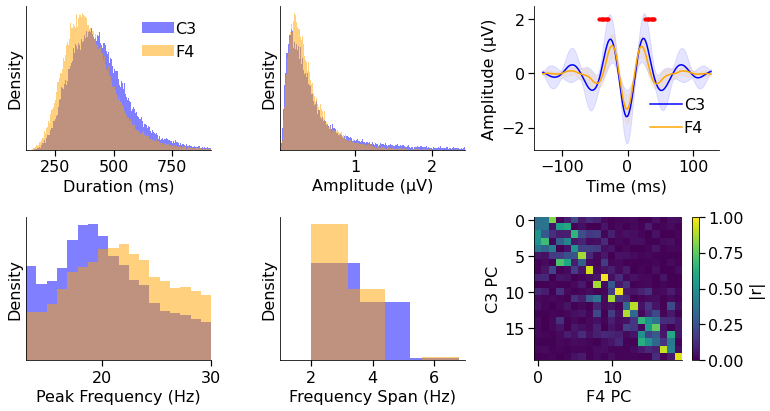

In [12]:
fig = plt.figure(figsize=(11, 6))
gs = gridspec.GridSpec(2, 3, figure=fig)

# Duration distribution
ax = fig.add_subplot(gs[0, 0])
_=ax.hist(all_bursts['fwhm_time'][c3_idx]*1e3, bins=700, alpha=0.5, color="blue", label="C3", density=True)
_=ax.hist(all_bursts['fwhm_time'][f4_idx]*1e3, bins=730, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlabel("Duration (ms)")
ax.set_xlim(np.percentile(all_bursts['fwhm_time']*1e3,[0,99]))
ax.set_ylabel("Density")
ax.set_yticks([])
ax.legend()

# Amplitude distribution (top left of second row)
ax = fig.add_subplot(gs[0, 1])
ax.hist(all_bursts['peak_amp_base'][c3_idx]*1e3, bins=1000, alpha=0.5, color="blue", label="C3", density=True)
ax.hist(all_bursts['peak_amp_base'][f4_idx]*1e3, bins=1000, alpha=0.5, color="orange", label="F4", density=True)
ax.set_xlabel("Amplitude (µV)")
ax.set_xlim(np.percentile(all_bursts['peak_amp_base']*1e3,[0,99]))
ax.set_ylabel("Density")
ax.set_yticks([])

# Peak frequency distribution (bottom left)
ax = fig.add_subplot(gs[1, 0])
ax.hist(all_bursts['peak_freq'][c3_idx], bins=18, alpha=0.5, color="blue", label="C3",density=True)
ax.hist(all_bursts['peak_freq'][f4_idx], bins=18, alpha=0.5, color="orange", label="F4",density=True)
ax.set_xlabel("Peak Frequency (Hz)")
ax.set_xlim(np.percentile(all_bursts['peak_freq'],[0,100]))
ax.set_ylabel("Density")
ax.set_yticks([])

# Frequency span distribution (bottom right)
ax = fig.add_subplot(gs[1, 1])
ax.hist(all_bursts['fwhm_freq'][c3_idx], bins=10, alpha=0.5, color="blue", label="C3",density=True)
ax.hist(all_bursts['fwhm_freq'][f4_idx], bins=10, alpha=0.5, color="orange", label="F4",density=True)
ax.set_xlim([1,7])
ax.set_xlabel("Frequency Span (Hz)")
ax.set_ylabel("Density")
ax.set_yticks([])

data = matrix_mean_waveforms_laplac_C3 - matrix_mean_waveforms_laplac_F4
# Perform cluster-based permutation test
T_obs, clusters, cluster_p_values, H0 = permutation_cluster_1samp_test(
    data, n_permutations=1000
)
ax = fig.add_subplot(gs[0,2])

# Plot mean waveforms
ax.plot(
    all_bursts['waveform_times']*1e3,
    np.mean(matrix_mean_waveforms_laplac_C3, axis=0),
    label="C3",
    color="blue",
)
ax.plot(
    all_bursts['waveform_times']*1e3,
    np.mean(matrix_mean_waveforms_laplac_F4, axis=0),
    label="F4",
    color="orange",
)

# Add shaded area using SEM around the mean waveform
ax.fill_between(
    all_bursts['waveform_times']*1e3,
    np.mean(matrix_mean_waveforms_laplac_C3, axis=0) - np.std(matrix_mean_waveforms_laplac_C3, axis=0),
    np.mean(matrix_mean_waveforms_laplac_C3, axis=0) + np.std(matrix_mean_waveforms_laplac_C3, axis=0),
    color="blue",
    alpha=0.1,
)
ax.fill_between(
    all_bursts['waveform_times']*1e3,
    np.mean(matrix_mean_waveforms_laplac_F4, axis=0) - np.std(matrix_mean_waveforms_laplac_F4, axis=0),
    np.mean(matrix_mean_waveforms_laplac_F4, axis=0) + np.std(matrix_mean_waveforms_laplac_F4, axis=0),
    color="orange",
    alpha=0.1,
)

# Plot significant clusters as dots
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] < 0.05:
        # Add dots at the time points of the cluster
        cluster_times = all_bursts['waveform_times'][c]*1e3
        cluster_midpoint = 2  # Midpoint between the offsets for clarity
        ax.scatter(cluster_times, [cluster_midpoint] * len(cluster_times), color='red', s=10)
ax.set_xlabel("Time (ms)")
ax.set_ylabel('Amplitude (µV)')
ax.legend(loc='lower right')

# Parameters
pcs_to_analyze_c = 20
min_pcs = min(model_laplac_C3.components_.shape[0], model_laplac_F4.components_.shape[0])

# Calculate the component correlation matrix
comp_corrmat_C3_F4 = np.zeros((min_pcs, min_pcs))
for i in range(min_pcs):
    for j in range(min_pcs):
        comp_corrmat_C3_F4[i, j] = np.abs(spearmanr(model_laplac_C3.components_[i, :], model_laplac_F4.components_[j, :])[0])

# Plot the correlation matrix
ax = fig.add_subplot(gs[1,2])
im=ax.imshow(comp_corrmat_C3_F4, aspect='auto', origin='upper', cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im,label='|r|')
ax.set_xlabel('F4 PC')
ax.set_ylabel('C3 PC')

plt.tight_layout()
plt.savefig('./figures/figure_xx_burst_features.pdf')


stat_fun(H1): min=0.040390 max=12.759421
Running initial clustering
Found 5 clusters
Permuting 9999 times...


  0%|          |  : 0/9999 [00:00<?,       ?it/s]

Computing cluster p-values
Done.
stat_fun(H1): min=0.000975 max=6.460130
Running initial clustering
Found 2 clusters
Permuting 9999 times...


  0%|          |  : 0/9999 [00:00<?,       ?it/s]

Computing cluster p-values
Done.


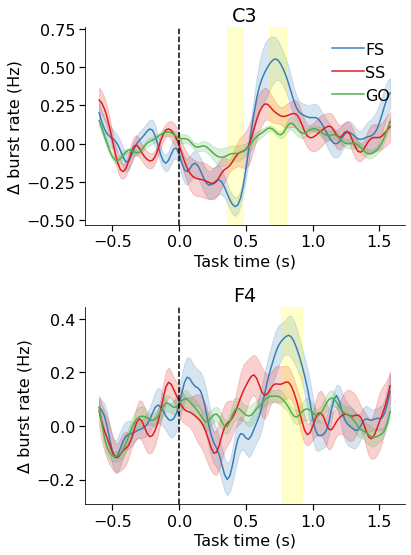

In [16]:
fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(2, 1, figure=fig)

ax = fig.add_subplot(gs[0, 0])
plot_overall_burst_rate(ax, c3_idx)
ax.legend()
ax.set_title('C3')

ax = fig.add_subplot(gs[1, 0])
plot_overall_burst_rate(ax, f4_idx)
ax.set_title('F4')

plt.tight_layout()
plt.savefig('./figures/figure_xx_burst_rate.pdf')